In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.columns

Index(['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'borough_y',
       'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres',
       'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse',
       'bldgclass', 'building_age'],
      dtype='str')

In [4]:
# Check for the number of datapoitns
df.shape

(34439, 19)

In [5]:
# Duplicate rows
df.duplicated().sum()

np.int64(1003)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
for col in df.columns:
    
    miss_perc = (df[col].isnull().sum() / len(df)) * 100
    
    if miss_perc < 10:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    else:
        print(f"Missing values in {col}: {miss_perc:.2f}%")

In [8]:
df.isnull().sum()

borough_x       0
block           0
lot             0
sale_price      0
zip_code        0
borough_y       0
yearbuilt       0
lotarea         0
bldgarea        0
resarea         0
comarea         0
unitsres        0
unitstotal      0
numfloors       0
latitude        0
longitude       0
landuse         0
bldgclass       0
building_age    0
dtype: int64

In [9]:
df.columns

Index(['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'borough_y',
       'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres',
       'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse',
       'bldgclass', 'building_age'],
      dtype='str')

In [10]:
numerical_features = [feature for feature in df.columns if df[feature].dtype in ['int64', 'float64']]

categorical_features = [feature for feature in df.columns if feature not in numerical_features]

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres', 'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse', 'building_age']
Categorical features: ['borough_y', 'bldgclass']


1. borough_y

In [11]:
df['borough_y'].value_counts()

borough_y
QN    12770
BK     9673
SI     3897
MN     3814
BX     3282
Name: count, dtype: int64

In [12]:
variation = df.groupby('borough_y')['sale_price'].agg(['mean', 'count'])
print(variation)

                   mean  count
borough_y                     
BK         1.368171e+06   9673
BX         9.319297e+05   3282
MN         1.567537e+06   3814
QN         9.878225e+05  12770
SI         1.035280e+06   3897


In [13]:
stats = df.groupby('borough_y')['sale_price'].agg(['mean','count'])

global_mean = df['sale_price'].mean()
k = 20

stats['smooth_mean'] = (
    stats['mean'] * stats['count'] + global_mean * k
) / (stats['count'] + k)

df['borough_mean_price'] = df['borough_y'].map(stats['smooth_mean'])

In [14]:
df['borough_mean_price'].value_counts()

borough_mean_price
9.880980e+05    12770
1.367749e+06     9673
1.035937e+06     3897
1.565433e+06     3814
9.333355e+05     3282
Name: count, dtype: int64

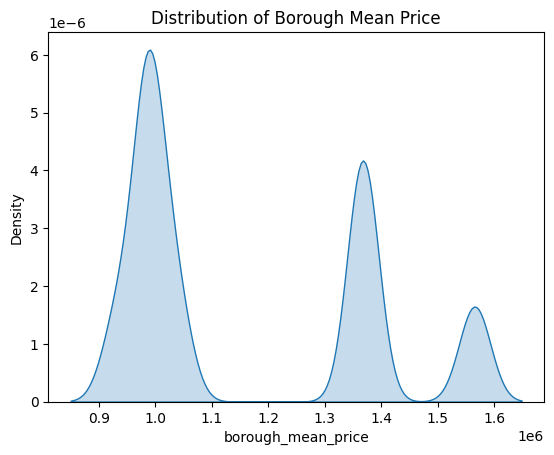

In [15]:
import seaborn as sns

sns.kdeplot(df['borough_mean_price'], fill=True)
plt.title("Distribution of Borough Mean Price")
plt.show()

In [16]:
df['borough_mean_price'].corr(df['sale_price'])

np.float64(0.18201269649348714)

2. 'bldgclass'

In [17]:
df['bldgclass'].str[0].nunique()
df['bldgclass'] = df['bldgclass'].str[0]

In [18]:
variation = df.groupby('bldgclass')['sale_price'].mean()
variation

bldgclass
A    1.025132e+06
B    1.183180e+06
C    1.362670e+06
D    8.627763e+05
E    2.394114e+06
F    2.362218e+06
G    1.716853e+06
H    2.989723e+06
I    2.655947e+06
J    5.703667e+06
K    2.257843e+06
M    1.583338e+06
N    1.598809e+06
O    1.919983e+06
P    2.915719e+06
Q    3.675000e+06
S    1.650241e+06
V    6.231600e+05
W    2.124049e+06
Z    2.418409e+06
Name: sale_price, dtype: float64

In [19]:
max_mean = max(variation)
min_mean = min(variation)

In [20]:
print(f"The difference between the max and min mean is: {max_mean - min_mean}, which is not small so the category does impact the price variation.")

The difference between the max and min mean is: 5080506.666666667, which is not small so the category does impact the price variation.


In [21]:
stats = df.groupby('bldgclass')['sale_price'].agg(['mean','count'])

global_mean = df['sale_price'].mean()
k = 20

stats['smooth_mean'] = (
    stats['mean'] * stats['count'] + global_mean * k
) / (stats['count'] + k)

df['bldgclass_mean_price'] = df['bldgclass'].map(stats['smooth_mean'])

#### Correlation of each feature with the Price feature


This code calculates the Pearson correlation between each numerical feature and sale_price. <br>
It helps identify the top features that are most strongly associated with the target variable 
and may be useful for building the prediction model.

In [22]:
price_correlations = df.drop(columns=['borough_y', 'bldgclass']).corr()['sale_price'].sort_values(ascending=False)
price_correlations.head(5)

sale_price              1.000000
bldgclass_mean_price    0.238396
borough_mean_price      0.182013
building_age            0.132110
landuse                 0.119923
Name: sale_price, dtype: float64

In [23]:
req_col = ['bldgclass_mean_price', 'borough_mean_price', 'building_age', 'landuse', 'sale_price']

#### Distribution of each feature

In [24]:
def plot_pdf(df, col1):
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='black')
    ax.set_facecolor('black')
    plt.style.use('dark_background')
    sns.distplot(df[col1])
    sns.despine(top=True, right=True, left=True, bottom=True)
    ax.grid(False)
    
    plt.title(f'Distribution of {col1}', fontsize=13, color='white')
    plt.xlabel(f'{col1}', fontsize=10, color='white')
    plt.ylabel('Frequency', fontsize=10, color='white')
    
    return 


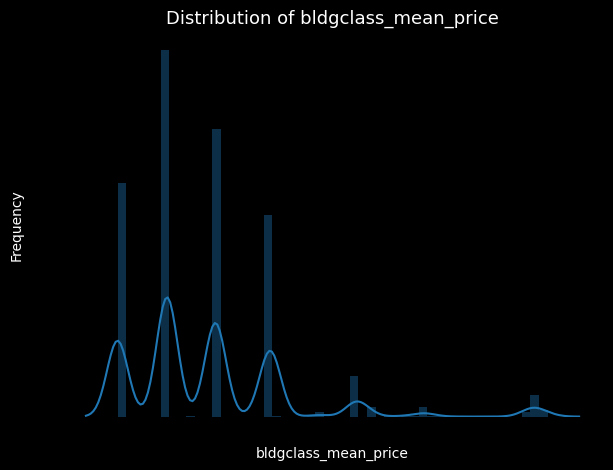

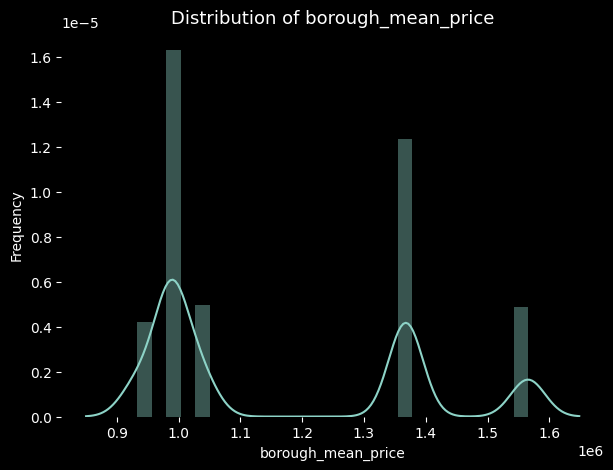

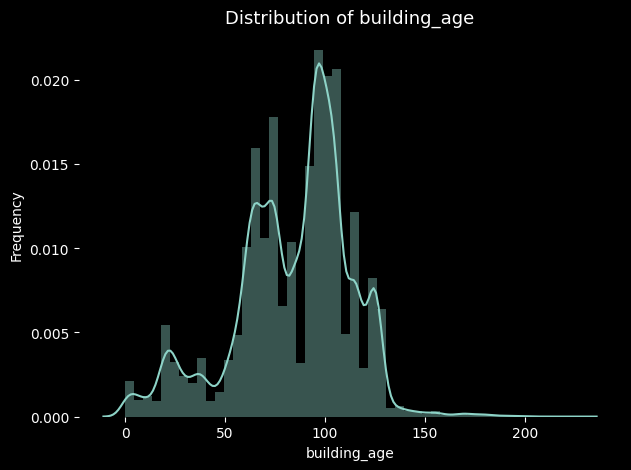

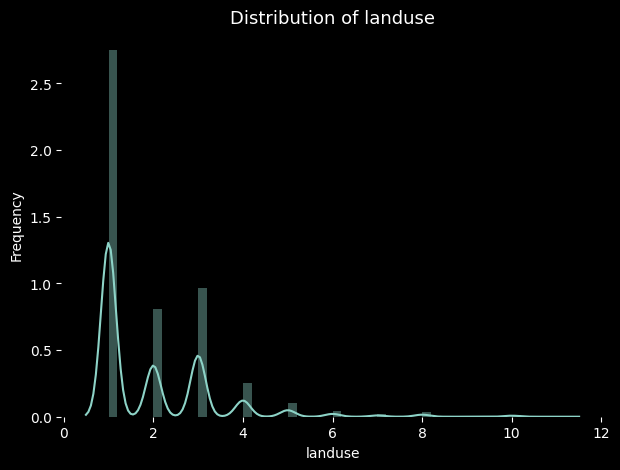

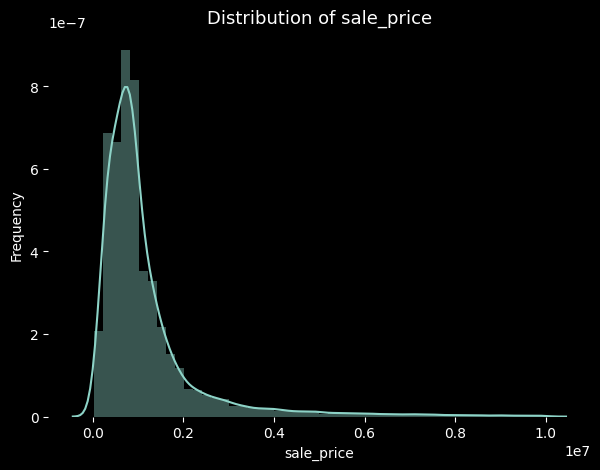

In [25]:
for col in df[req_col].columns:
    plot_pdf(df, col)

## Applying Scaling 

In [26]:
def standard_scale(df, column):
    """
    X_scaled = (X - X.mean()) / X.std()
    """
    mean_val = df[column].mean()
    std_val = df[column].std()

    df[column + "_scaled"] = (df[column] - mean_val) / std_val

    return 

In [27]:
df["bldgclass_mean_price_log"] = np.log1p(df["bldgclass_mean_price"])

In [28]:
standard_scale(df, 'bldgclass_mean_price_log')

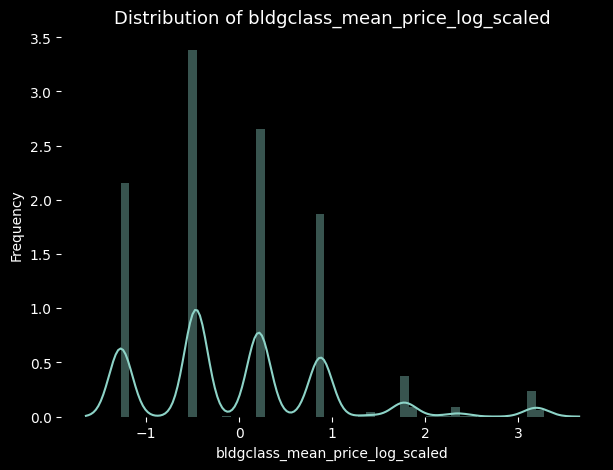

In [29]:
plot_pdf(df, 'bldgclass_mean_price_log_scaled')

In [30]:
df[df['bldgclass_mean_price_log_scaled'] > 4].shape[0]

0

#### Pipeline Structure
> building_class → mean(sale_price) → log → standard scaling

2. 'borough_mean_price'

In [31]:
standard_scale(df, 'borough_mean_price')

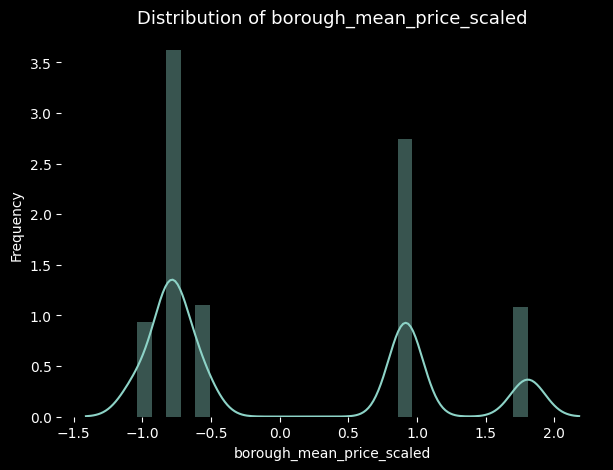

In [32]:
plot_pdf(df, 'borough_mean_price_scaled')

#### Pipeline
>  borough_mean_price → mean(sale_price) → standard scaling

3. 'building_age'

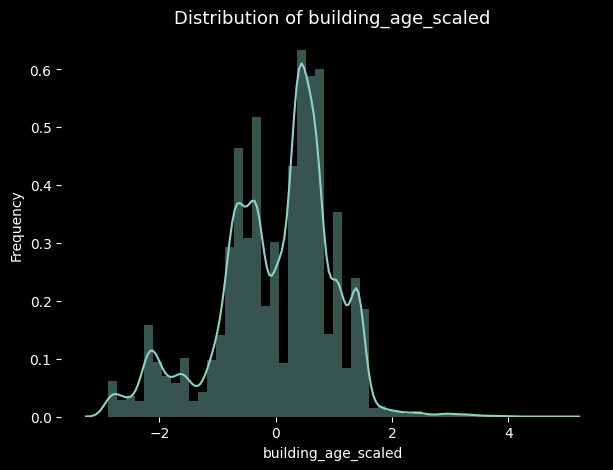

In [33]:
standard_scale(df, 'building_age')
plot_pdf(df, 'building_age_scaled')

#### Pipeline
>  building_age → mean(sale_price) → standard scaling

4. landuse

In [34]:
df['landuse'].nunique()

11

In [35]:
stats = df.groupby('landuse')['sale_price'].agg(['mean','count'])

global_mean = df['sale_price'].mean()
k = 20

stats['smooth_mean'] = (
    stats['mean'] * stats['count'] + global_mean * k
) / (stats['count'] + k)

df['landuse_mean_price'] = df['landuse'].map(stats['smooth_mean'])

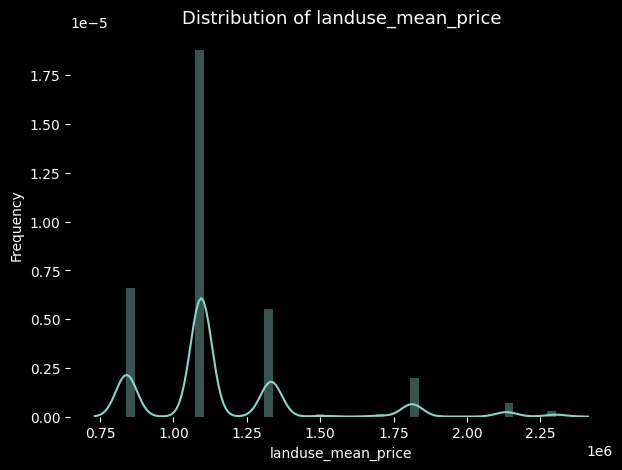

In [36]:
plot_pdf(df, 'landuse_mean_price')

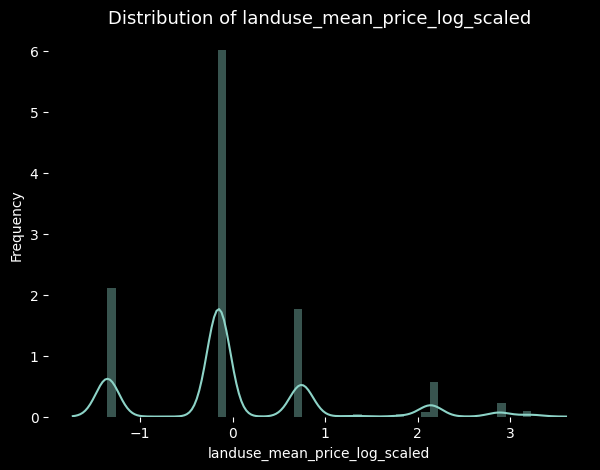

In [37]:
# Apply log transformation 
df["landuse_mean_price_log"] = np.log(df["landuse_mean_price"])

standard_scale(df, 'landuse_mean_price_log')
plot_pdf(df, 'landuse_mean_price_log_scaled')

#### Pipeline
>  landuse → mean(sale_price) → log_transformation → standard scaling

In [38]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [39]:
class Multiple_linear_regression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis = 1)  # Inserts the one column at the start of the array
        
        beta = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = beta[0]
        self.coef_ = beta[1:]

        
    def predict(self, X_test):
        y_pred = np.dot(X_test, self.coef_) + self.intercept_
        return y_pred


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['borough_mean_price_scaled', 'bldgclass_mean_price_log_scaled', 'building_age_scaled', 'landuse_mean_price_log_scaled']],
    df['sale_price'],
    test_size=0.2,
    random_state=42
)

In [41]:
reg = Multiple_linear_regression()
reg.fit(X_train, y_train)
reg.predict(X_test)
r2 = r2_score(y_test, reg.predict(X_test))

print(f"R-squared: {r2:.4f}")

R-squared: 0.0911


### Test Data

In [43]:
# Mean of the feature
bldg_mean = df['bldgclass_mean_price_log'].mean() 

# Standard deviation

In [44]:
def predict_price(bldgclass: str, borough: str, building_age: float, landuse: int):

    # --- Mean encoding dictionaries ---
    bldgclass_price_mean = {
        'A':1025132,'B':1183180,'C':1362670,'D':862776,'E':2394114,
        'F':2362218,'G':1716853,'H':2989723,'I':2655947,'J':5703667,
        'K':2257843,'M':1583338,'N':1598809,'O':1919983,'P':2915719,
        'Q':3675000,'S':1650241,'V':623160,'W':2124049,'Z':2418409
    }

    borough_price_mean = {
        'BK':1368171,
        'BX':931929,
        'MN':1567537,
        'QN':987822,
        'SI':1035280
    }

    landuse_price_mean = stats['smooth_mean'].to_dict()

    # --- Convert categories to encoded values ---
    bldgclass_mean = bldgclass_price_mean[bldgclass]
    borough_mean = borough_price_mean[borough]
    landuse_mean = landuse_price_mean[landuse]

    # --- Log transformation ---
    bldgclass_log = np.log1p(bldgclass_mean)
    landuse_log = np.log1p(landuse_mean)

    # --- Stored training statistics ---
    bldg_mean = 13.938644735559976
    bldg_std = 0.2119941668962619

    borough_mean_train = 1163986.9206558461
    borough_std = 222136.5913877893

    age_mean = 84.05802129441321
    age_std = 29.08177002265047

    landuse_mean_train = 13.939050193803778
    landuse_std = 0.22040591843972304

    # --- Standard scaling ---
    bldg_scaled = (bldgclass_log - bldg_mean) / bldg_std
    borough_scaled = (borough_mean - borough_mean_train) / borough_std
    age_scaled = (building_age - age_mean) / age_std
    landuse_scaled = (landuse_log - landuse_mean_train) / landuse_std

    # --- Feature vector ---
    X = np.array([[borough_scaled,
                   bldg_scaled,
                   age_scaled,
                   landuse_scaled]])

    # --- Prediction ---
    pred = reg.predict(X)

    return pred[0]

In [45]:
predict_price(
    bldgclass="A",
    borough="MN",
    building_age=60,
    landuse=2
)

np.float64(1684470.4218394395)